In [1]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [2]:
import pandas as pd
import numpy as np

In [3]:
housing = pd.read_csv("housing.csv")
hpi = pd.read_csv("hpi_master (1).csv")

race = pd.read_excel("Race.xlsx")
age_sex = pd.read_excel("Resident Population by Age and Sex.xlsx")
population = pd.read_excel("Total Population by County.xlsx")

In [4]:
def explore(df, name):
    print("==============")
    print("Dataset:", name)
    print("==============")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nColumns:")
    print(df.columns)
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())
    
    print("\nSummary Statistics:")
    print(df.describe(include='all'))

In [5]:
explore(housing, "Housing Data")
explore(hpi, "HPI Data")
explore(race, "Race Data")
explore(age_sex, "Age & Sex Data")
explore(population, "Population Data")

Dataset: Housing Data

Shape:
(20640, 10)

Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate Rows:
0

Summary Statistics:
           longitude      latitude  housing_median_age   total_rooms  \
count   2

In [6]:
num_cols = housing.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = housing[col].quantile(0.25)
    Q3 = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = housing[(housing[col] < lower) | (housing[col] > upper)].shape[0]
    
    print(col, "Outliers:", outliers)

longitude Outliers: 0
latitude Outliers: 0
housing_median_age Outliers: 0
total_rooms Outliers: 1287
total_bedrooms Outliers: 1271
population Outliers: 1196
households Outliers: 1220
median_income Outliers: 681
median_house_value Outliers: 1071


In [7]:
(housing.isnull().sum() / len(housing)) * 100


longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

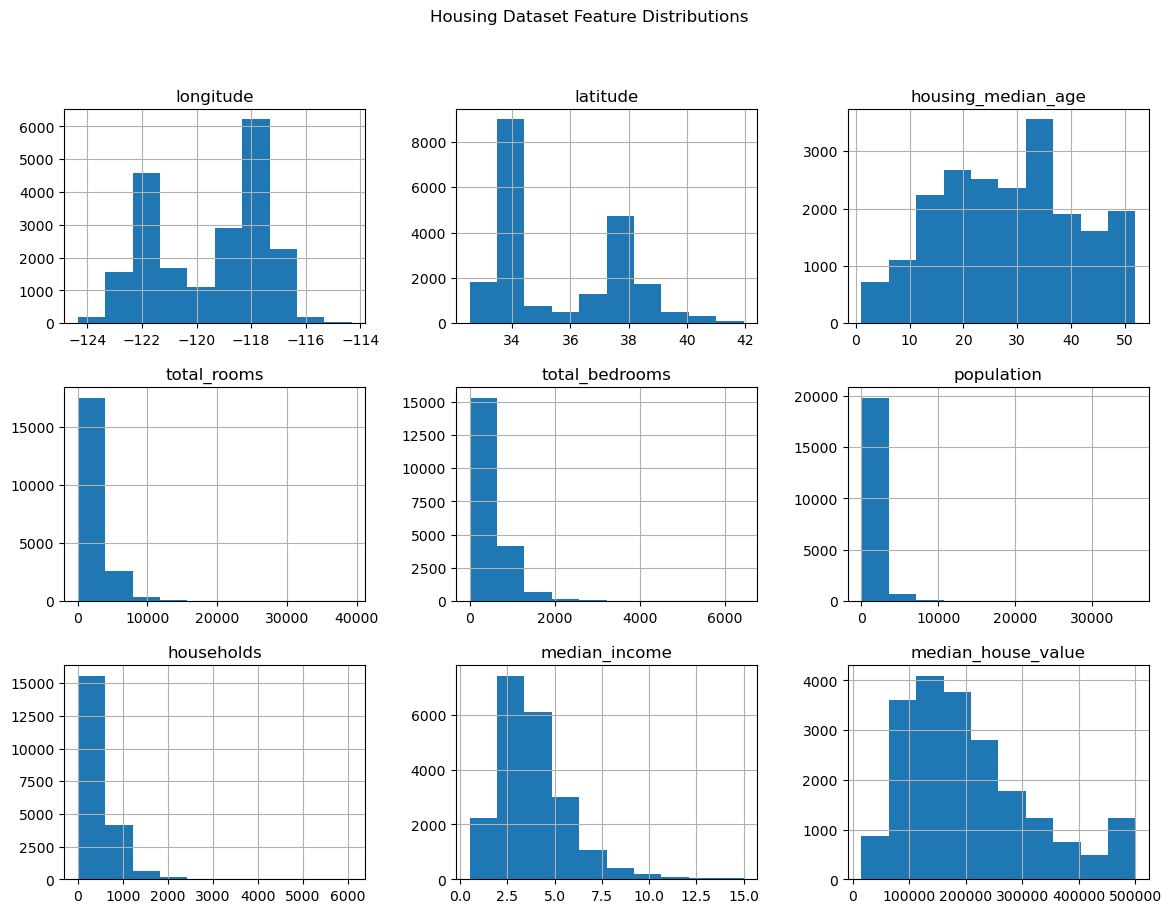

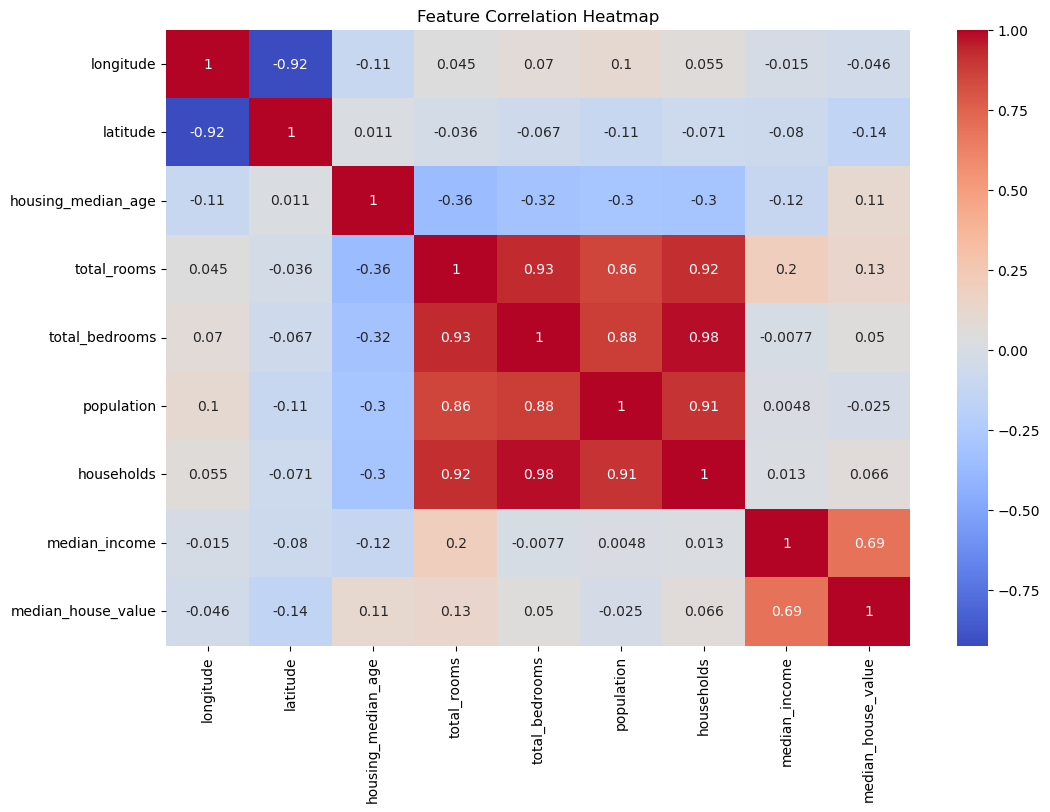

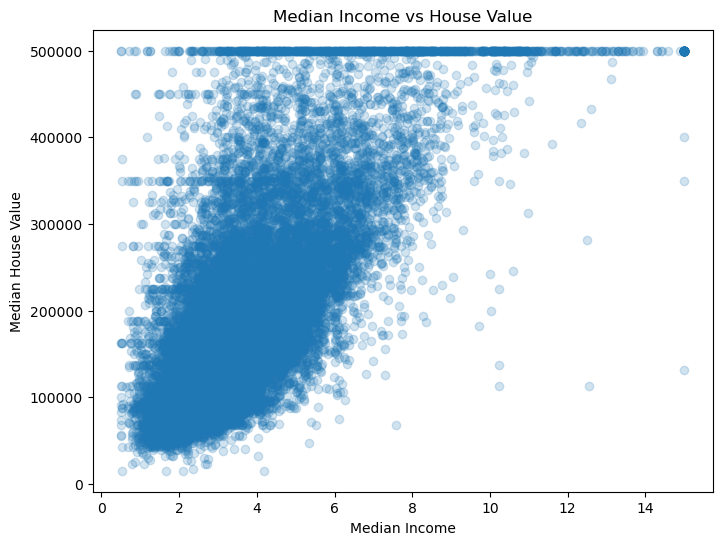

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram visualization
housing.hist(figsize=(14,10))
plt.suptitle("Housing Dataset Feature Distributions")
plt.show()

# Correlation heatmap using only numeric columns
numeric_housing = housing.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_housing.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# Median income vs house value
plt.figure(figsize=(8,6))
plt.scatter(housing["median_income"], housing["median_house_value"], alpha=0.2)
plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()